# CD-MSC Data Explorer
Explore raw audio, log-mel features, and dataset statistics for the BioDCASE 2026 mosquito task.

In [14]:
# ── Parameters — edit these ──────────────────────────────────────────────────
DATA_ROOT   = "data/Development_data"
AUDIO_DIR   = f"{DATA_ROOT}/raw_audio"
META_DIR    = f"{DATA_ROOT}/metadata"
FEATURE_DIR = f"{DATA_ROOT}/feature"

SAMPLE_RATE = 8000          # Hz (matches extraction config)
N_MELS      = 64            # mel bins used during feature extraction
N_FFT       = 1024
HOP_LENGTH  = 320           # ~40 ms hop at 8 kHz
FMIN        = 0
FMAX        = 4000          # Nyquist for 8 kHz

# Samples to visualise — change species/domain or pick explicit IDs
VIZ_IDS = [
    "S_1_D_1_100",   # Aedes aegypti, D1
    "S_3_D_1_100",   # Culex quinquefasciatus, D1
    "S_4_D_1_100",   # Anopheles gambiae, D1
]
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import os, json, re
from pathlib import Path
from collections import Counter

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import IPython.display as ipd

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## 1  Directory structure

In [3]:
def show_tree(root, max_files=5, indent=0):
    root = Path(root)
    prefix = "  " * indent
    children = sorted(root.iterdir())
    dirs  = [c for c in children if c.is_dir()]
    files = [c for c in children if c.is_file()]
    for d in dirs:
        n = sum(1 for _ in d.rglob("*") if _.is_file())
        print(f"{prefix}📁 {d.name}/  ({n} files)")
        show_tree(d, max_files, indent + 1)
    for i, f in enumerate(files):
        if i < max_files:
            size = f.stat().st_size
            print(f"{prefix}📄 {f.name}  ({size/1024:.1f} KB)")
        elif i == max_files:
            print(f"{prefix}   … {len(files) - max_files} more files")
            break

show_tree(DATA_ROOT)

📁 feature/  (4 files)
  📄 test_features.pkl  (1393900.2 KB)
  📄 training_feature_stats.json  (3.6 KB)
  📄 training_features.pkl  (3599977.6 KB)
  📄 validation_features.pkl  (500314.0 KB)
📁 metadata/  (5 files)
  📄 Test_ids.txt  (359.3 KB)
  📄 TrainVal_ids.txt  (3278.5 KB)
  📄 Training_ids.txt  (2868.8 KB)
  📄 Validation_ids.txt  (409.8 KB)
  📄 split_summary.json  (2.0 KB)
📁 raw_audio/  (271380 files)
  📄 S_1_D_1_1.wav  (10.9 KB)
  📄 S_1_D_1_10.wav  (2.5 KB)
  📄 S_1_D_1_100.wav  (661.5 KB)
  📄 S_1_D_1_101.wav  (2976.8 KB)
  📄 S_1_D_1_102.wav  (3630.5 KB)
     … 271375 more files
📄 .DS_Store  (14.0 KB)


## 2  Dataset statistics

In [4]:
FILE_PAT = re.compile(r"^S_(\d+)_D_(\d+)_\d+$")
SPECIES = {
    "1": "Ae. aegypti", "2": "Ae. albopictus", "3": "Cx. quinquefasciatus",
    "4": "An. gambiae",  "5": "An. arabiensis", "6": "An. dirus",
    "7": "Cx. pipiens",  "8": "An. minimus",    "9": "An. stephensi",
}

def load_ids(path):
    return [l.strip() for l in open(path) if l.strip()]

def parse_counts(ids):
    sp, dom = Counter(), Counter()
    for fid in ids:
        m = FILE_PAT.match(fid)
        if m:
            sp[SPECIES[m.group(1)]] += 1
            dom[f"D{m.group(2)}"] += 1
    return sp, dom

splits = {"train": "Training_ids.txt", "val": "Validation_ids.txt", "test": "Test_ids.txt"}
all_counts = {}
for split, fname in splits.items():
    ids = load_ids(f"{META_DIR}/{fname}")
    all_counts[split] = parse_counts(ids)
    print(f"{split:6s}  {len(ids):7,d} clips")

train   213,647 clips
val      30,516 clips
test     27,217 clips


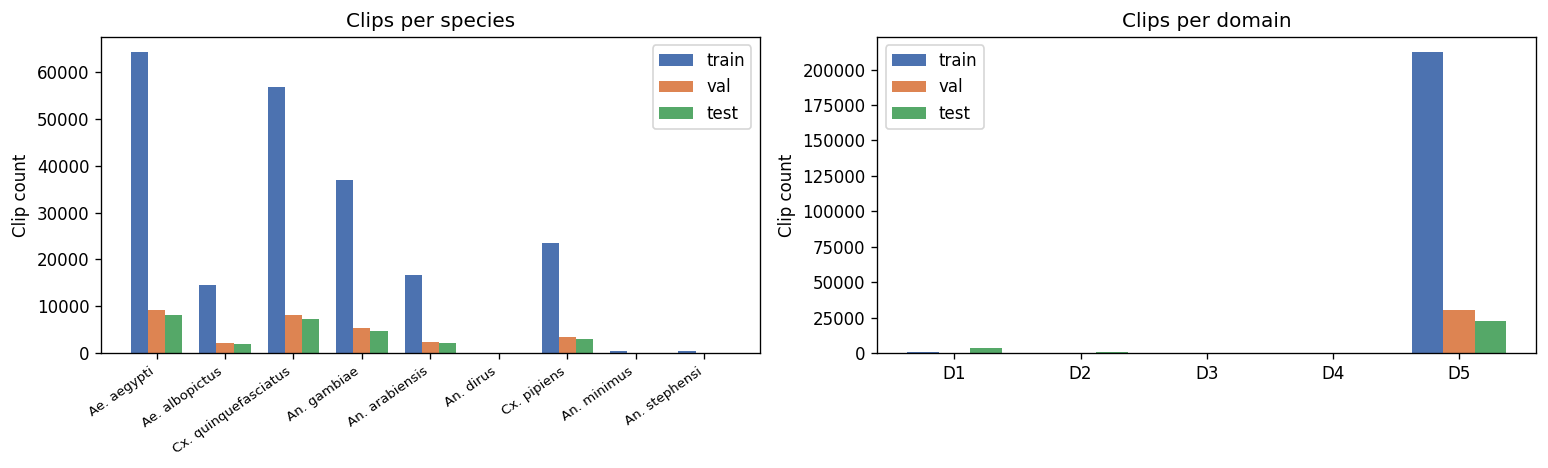

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Species counts per split
ax = axes[0]
sp_names = list(SPECIES.values())
x = np.arange(len(sp_names))
w = 0.25
colors = ["#4c72b0", "#dd8452", "#55a868"]
for i, (split, (sp_cnt, _)) in enumerate(all_counts.items()):
    ax.bar(x + i * w, [sp_cnt[s] for s in sp_names], w, label=split, color=colors[i])
ax.set_xticks(x + w)
ax.set_xticklabels(sp_names, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Clip count")
ax.set_title("Clips per species")
ax.legend()

# Domain counts per split
ax = axes[1]
dom_names = [f"D{i}" for i in range(1, 6)]
x = np.arange(len(dom_names))
for i, (split, (_, dom_cnt)) in enumerate(all_counts.items()):
    ax.bar(x + i * w, [dom_cnt[d] for d in dom_names], w, label=split, color=colors[i])
ax.set_xticks(x + w)
ax.set_xticklabels(dom_names)
ax.set_ylabel("Clip count")
ax.set_title("Clips per domain")
ax.legend()

plt.tight_layout()
plt.show()

## 3  Waveform

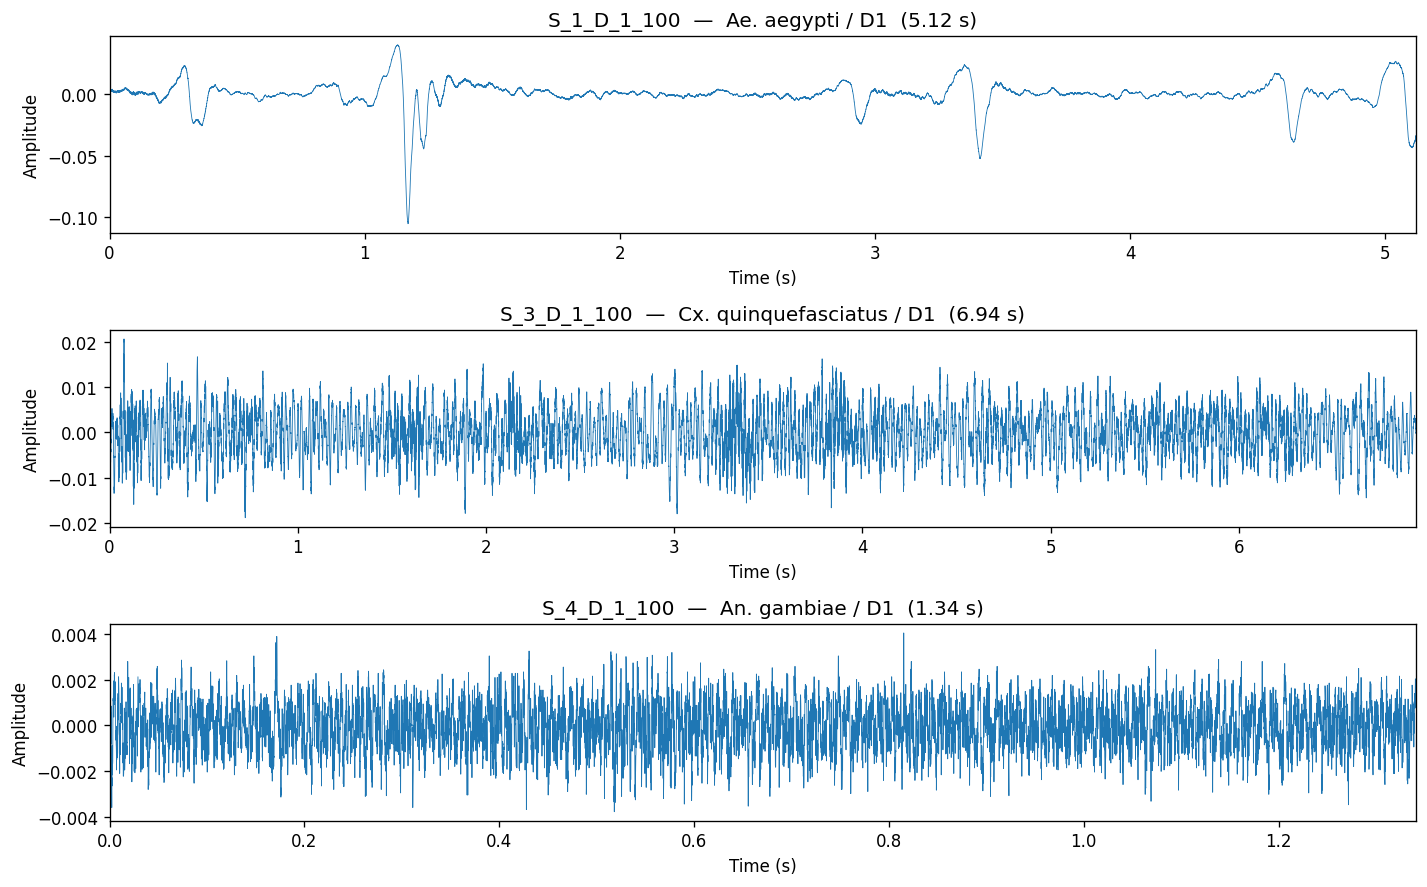

In [9]:
def load_audio(file_id, audio_dir=AUDIO_DIR, sr=SAMPLE_RATE):
    path = Path(audio_dir) / f"{file_id}.wav"
    wav, _ = librosa.load(path, sr=sr, mono=True)
    return wav

def label(file_id):
    m = FILE_PAT.match(file_id)
    return f"{SPECIES[m.group(1)]} / D{m.group(2)}"

fig, axes = plt.subplots(len(VIZ_IDS), 1, figsize=(12, 2.5 * len(VIZ_IDS)), sharex=False)
if len(VIZ_IDS) == 1:
    axes = [axes]

wavs = {}
for ax, fid in zip(axes, VIZ_IDS):
    wav = load_audio(fid)
    wavs[fid] = wav
    t = np.arange(len(wav)) / SAMPLE_RATE
    ax.plot(t, wav, linewidth=0.5)
    ax.set_title(f"{fid}  —  {label(fid)}  ({len(wav)/SAMPLE_RATE:.2f} s)")
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time (s)")
    ax.set_xlim(0, t[-1])

plt.tight_layout()
plt.show()

In [7]:
# Play audio inline (change index to listen to different clips)
PLAY_IDX = 0
fid = VIZ_IDS[PLAY_IDX]
print(f"Playing: {fid}  ({label(fid)})")
ipd.display(ipd.Audio(wavs[fid], rate=SAMPLE_RATE))

Playing: S_1_D_1_100  (Ae. aegypti / D1)


## 4  Log-mel spectrogram

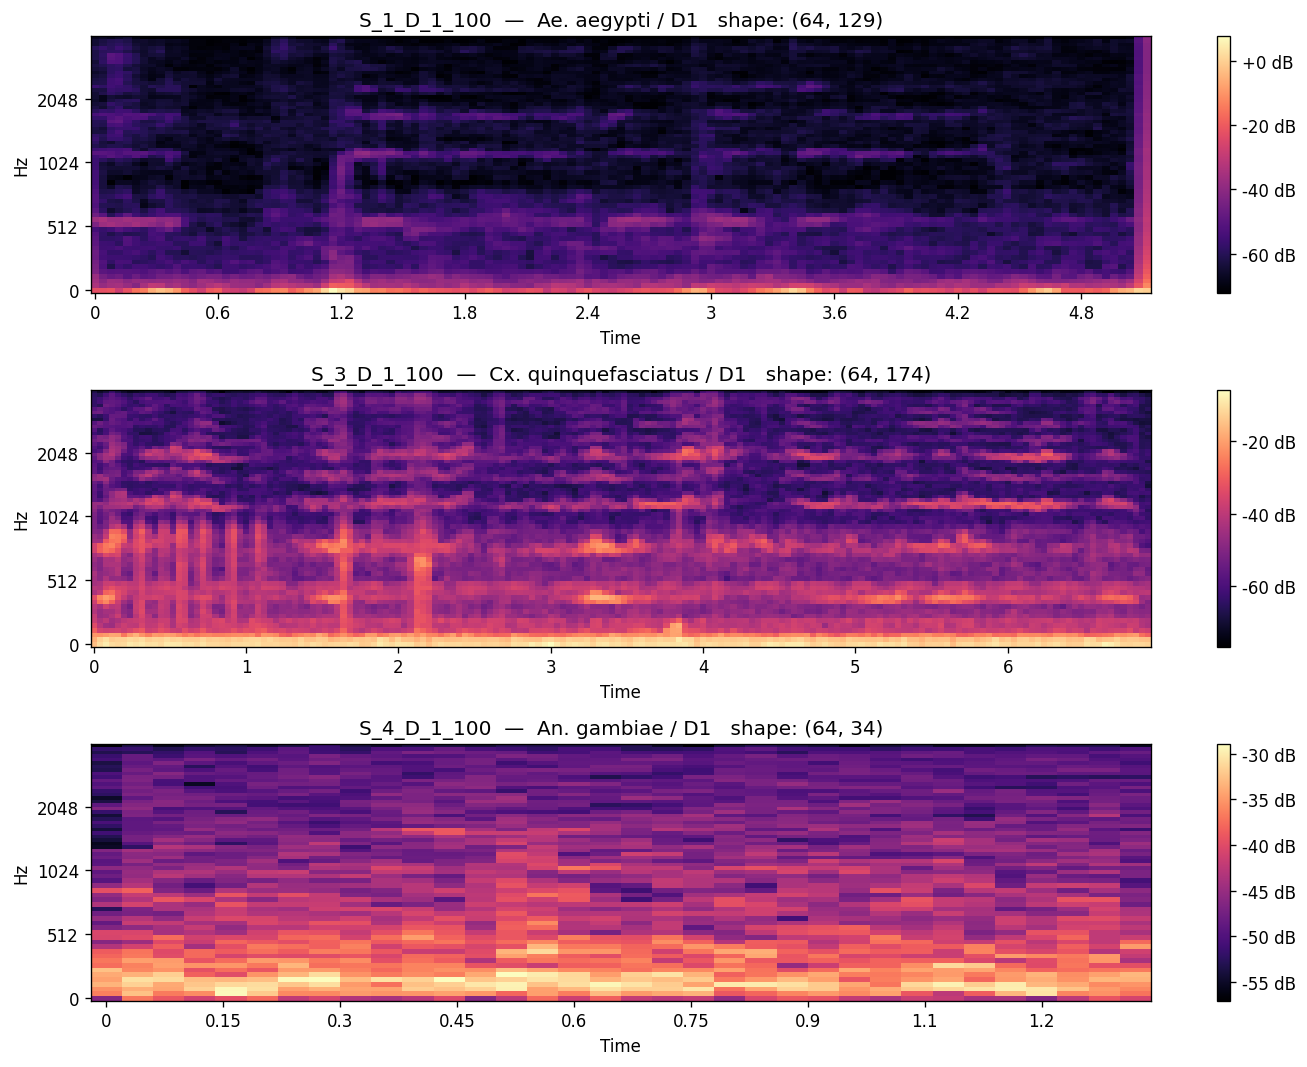

In [11]:
def compute_logmel(wav, sr=SAMPLE_RATE, n_fft=N_FFT, hop=HOP_LENGTH,
                   n_mels=N_MELS, fmin=FMIN, fmax=FMAX):
    mel = librosa.feature.melspectrogram(
        y=wav, sr=sr, n_fft=n_fft, hop_length=hop,
        n_mels=n_mels, fmin=fmin, fmax=fmax
    )
    return librosa.power_to_db(mel, ref=1.0)  # [n_mels, T]

fig, axes = plt.subplots(len(VIZ_IDS), 1, figsize=(12, 3 * len(VIZ_IDS)))
if len(VIZ_IDS) == 1:
    axes = [axes]

for ax, fid in zip(axes, VIZ_IDS):
    spec = compute_logmel(wavs[fid])  # [n_mels, T]
    img = librosa.display.specshow(
        spec, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel", fmin=FMIN, fmax=FMAX, ax=ax
    )
    fig.colorbar(img, ax=ax, format="%+.0f dB")
    ax.set_title(f"{fid}  —  {label(fid)}   shape: {spec.shape}")

plt.tight_layout()
plt.show()

## 5  Feature stats (mean / std across training set)

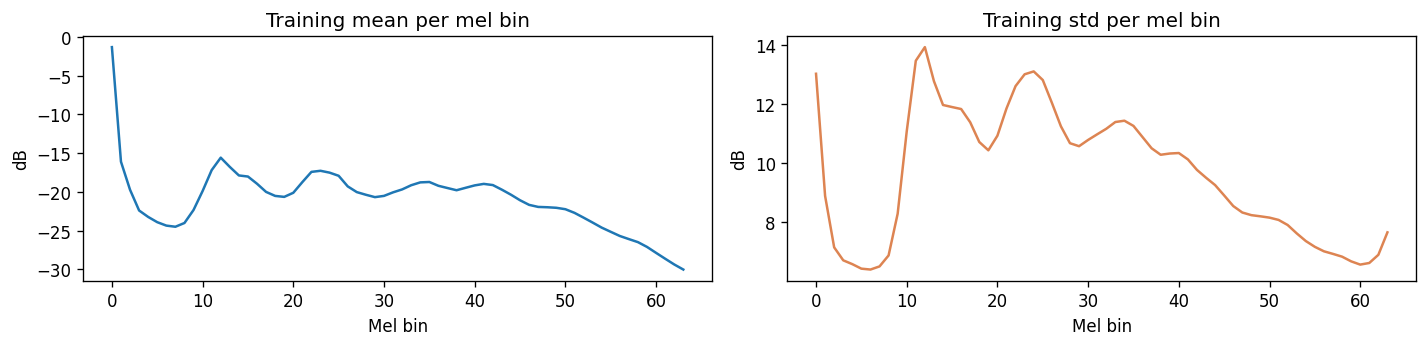

Total training frames: 14,291,071


In [15]:
stats_path = Path(FEATURE_DIR) / "training_feature_stats.json"
stats = json.loads(stats_path.read_text())
mean = np.array(stats["mean"])  # [n_mels]
std  = np.array(stats["std"])
bins = np.arange(len(mean))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(bins, mean)
axes[0].set_xlabel("Mel bin")
axes[0].set_ylabel("dB")
axes[0].set_title("Training mean per mel bin")

axes[1].plot(bins, std, color="#dd8452")
axes[1].set_xlabel("Mel bin")
axes[1].set_ylabel("dB")
axes[1].set_title("Training std per mel bin")

plt.tight_layout()
plt.show()
print(f"Total training frames: {stats['num_frames']:,}")

## 6  Normalised spectrogram (what the model sees)

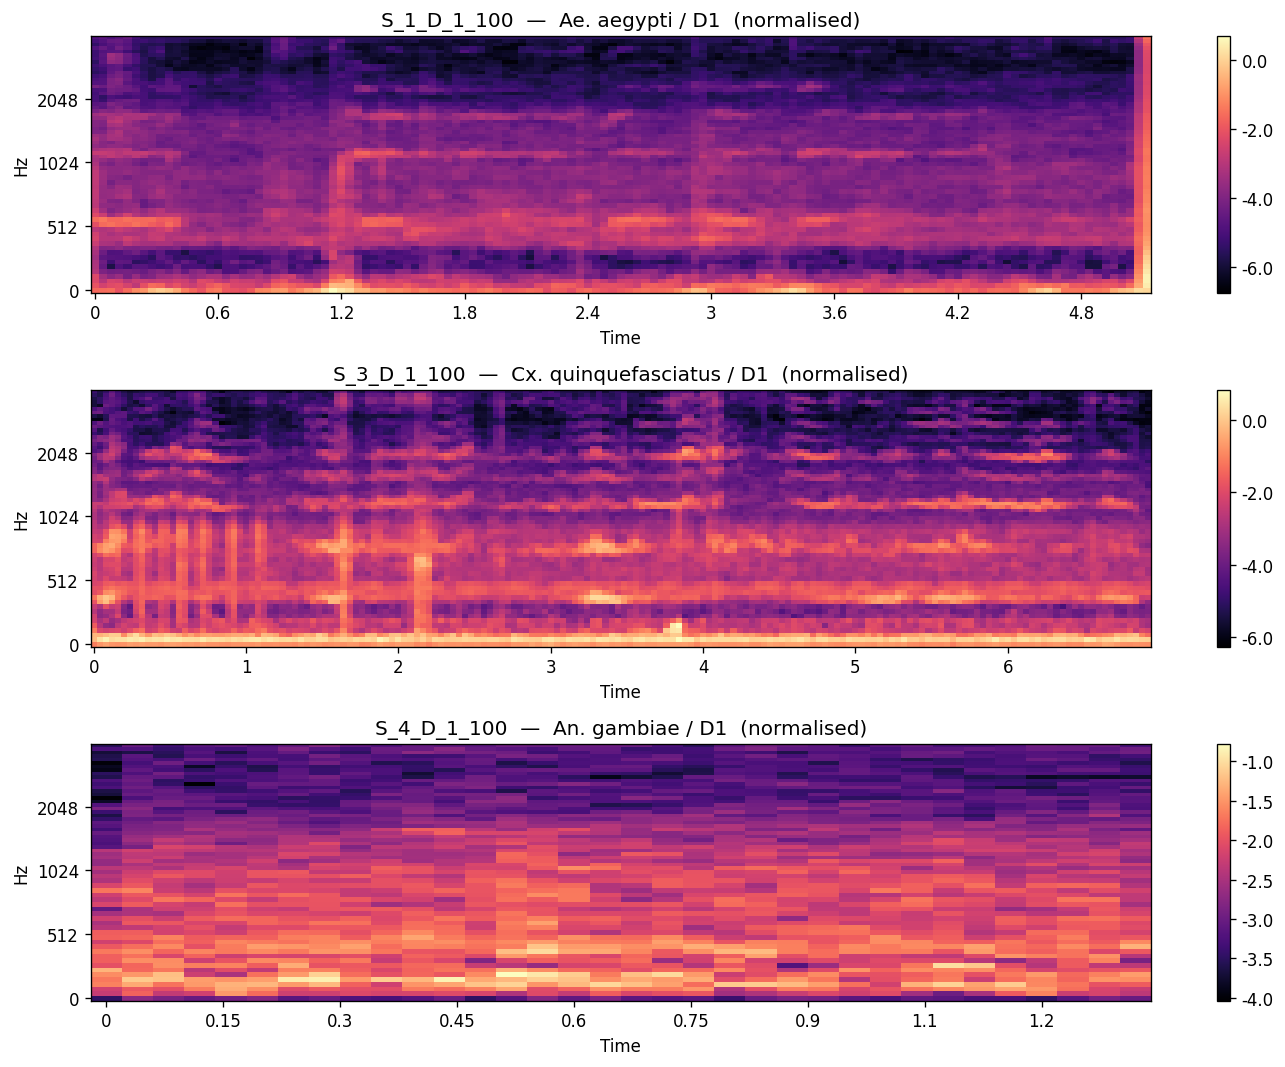

In [16]:
fig, axes = plt.subplots(len(VIZ_IDS), 1, figsize=(12, 3 * len(VIZ_IDS)))
if len(VIZ_IDS) == 1:
    axes = [axes]

for ax, fid in zip(axes, VIZ_IDS):
    spec = compute_logmel(wavs[fid])          # [n_mels, T]
    spec_norm = (spec - mean[:, None]) / std[:, None]   # z-score each mel bin
    img = librosa.display.specshow(
        spec_norm, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel", fmin=FMIN, fmax=FMAX, ax=ax
    )
    fig.colorbar(img, ax=ax, format="%.1f")
    ax.set_title(f"{fid}  —  {label(fid)}  (normalised)")

plt.tight_layout()
plt.show()

## 7  Interactive sample inspector

In [ ]:
import random
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

SPECIES_NAME_TO_ID = {v: k for k, v in SPECIES.items()}

def _resolve_species(species_input):
    s = str(species_input).strip()
    if s in SPECIES:
        return s
    if s in SPECIES_NAME_TO_ID:
        return SPECIES_NAME_TO_ID[s]
    s_low = s.lower()
    for k, v in SPECIES.items():
        if s_low in v.lower():
            return k
    raise ValueError(f"Unknown species: {species_input!r}. Options: {list(SPECIES.values())}")

def _resolve_domain(domain_input):
    d = str(domain_input).strip().upper()
    if not d.startswith("D"):
        d = "D" + d
    if not re.match(r"^D[1-5]$", d):
        raise ValueError(f"Unknown domain: {domain_input!r}. Options: D1–D5")
    return d

def _build_split_index():
    if not hasattr(_build_split_index, "_cache"):
        _build_split_index._cache = {
            "trainval": set(load_ids(f"{META_DIR}/TrainVal_ids.txt")),
            "test":     set(load_ids(f"{META_DIR}/Test_ids.txt")),
        }
    return _build_split_index._cache

VIZ_SECONDS = 5.0

def inspect_sample(species, domain, n=1, seed=None):
    sp_id   = _resolve_species(species)
    dom     = _resolve_domain(domain)
    sp_name = SPECIES[sp_id]
    pattern = re.compile(rf"^S_{sp_id}_D_{dom[1:]}_\d+$")

    index = _build_split_index()
    matches = {
        split: sorted(fid for fid in ids if pattern.match(fid))
        for split, ids in index.items()
    }

    total = sum(len(v) for v in matches.values())
    if total == 0:
        print(f"No clips found for {sp_name} / {dom}.")
        return

    print(f"{'─'*52}")
    print(f"  Species : {sp_name}")
    print(f"  Domain  : {dom}")
    for split, ids in matches.items():
        print(f"  {split:8s}: {len(ids):,} clips")
    print(f"  Total   : {total:,} clips")
    print(f"{'─'*52}\n")

    all_ids = [(fid, split) for split, ids in matches.items() for fid in ids]
    rng = random.Random(seed)
    chosen = rng.sample(all_ids, min(n, total))

    for chosen_id, chosen_split in chosen:
        print(f"  Sampled : {chosen_id}  (from {chosen_split})")
        wav      = load_audio(chosen_id)
        duration = len(wav) / SAMPLE_RATE

        spec      = compute_logmel(wav)
        spec_norm = (spec - mean[:, None]) / std[:, None]

        max_frames = int(VIZ_SECONDS * SAMPLE_RATE / HOP_LENGTH)
        spec_norm  = spec_norm[:, :max_frames]
        viz_dur    = min(duration, VIZ_SECONDS)
        freq_axis  = librosa.mel_frequencies(n_mels=N_MELS, fmin=FMIN, fmax=FMAX)

        # Fixed width based on VIZ_SECONDS — short clips end early and pad
        fig, axes = plt.subplots(
            2, 1, figsize=(VIZ_SECONDS * 1.8, 5),
            gridspec_kw={"height_ratios": [1, 2]},
        )

        # Waveform coloured by amplitude
        wav_clip = wav[:int(viz_dur * SAMPLE_RATE)]
        t = np.arange(len(wav_clip)) / SAMPLE_RATE
        points   = np.array([t, wav_clip]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        norm_wav = Normalize(vmin=-1, vmax=1)
        lc = LineCollection(segments, cmap="RdBu_r", norm=norm_wav, linewidth=1.2)
        lc.set_array(wav_clip[:-1])
        axes[0].add_collection(lc)
        axes[0].set_xlim(0, VIZ_SECONDS)          # fixed x range
        axes[0].set_ylim(wav_clip.min() * 1.1, wav_clip.max() * 1.1)
        axes[0].axhline(0, color="k", linewidth=0.4, linestyle="--")
        axes[0].set_ylabel("Amplitude")
        axes[0].set_xlabel("Time (s)")
        axes[0].set_title(
            f"{chosen_id}  —  {sp_name} / {dom}  "
            f"(showing {viz_dur:.1f} / {duration:.1f} s)  [{chosen_split}]",
            fontsize=11, fontweight="bold",
        )
        fig.colorbar(lc, ax=axes[0], label="Amplitude", pad=0.01, fraction=0.03)

        # Spectrogram — image extent ends at viz_dur, axes goes to VIZ_SECONDS
        ax = axes[1]
        im = ax.imshow(
            spec_norm,
            origin="lower", aspect="auto",
            interpolation="nearest", cmap="magma",
            extent=[0, viz_dur, freq_axis[0], freq_axis[-1]],
        )
        ax.set_xlim(0, VIZ_SECONDS)               # fixed x range
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Frequency (Hz)")
        ax.set_title("Normalised log-mel spectrogram (z-scored per mel bin)", fontsize=10)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v)}"))
        fig.colorbar(im, ax=ax, label="z-score", pad=0.01, fraction=0.03)

        plt.tight_layout()
        plt.show()
        ipd.display(ipd.Audio(wav, rate=SAMPLE_RATE))


inspect_sample("aegypti", "D1", n=2)